## Step 1: Environment Setup & Library Imports
We import essential libraries for scientific computing, data wrangling, statistical visualization, machine learning, and model persistence.

In [1]:
import os
import sys
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Plotting aesthetics
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version:  {np.__version__}")
print("All libraries imported successfully!")

Pandas Version: 3.0.1
NumPy Version:  2.4.3
All libraries imported successfully!


## Step 2: Data Ingestion & Structural Inspection
We load the BRFSS 2015 dataset from the local `data/` directory and perform initial schema inspection.

In [2]:
DATA_PATH = os.path.join('data', 'heart_disease_health_indicators_BRFSS2015.csv')

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw Dataset Dimensions: {df_raw.shape[0]:,} records across {df_raw.shape[1]} columns.\n")
print("Column Data Types & Memory Usage:")
df_raw.info()

Raw Dataset Dimensions: 253,680 records across 22 columns.

Column Data Types & Memory Usage:
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost          

## Step 3: Robust Data Cleaning & Preprocessing
In this section, we audit:
1. **Missing values (NaNs):** Ensure zero null entries or apply median/mode imputation.
2. **Duplicate rows:** Detect and remove duplicate survey responses.
3. **Data Types:** Optimize float columns to integers for memory efficiency and computational speed.
4. **Summary Descriptive Statistics:** Inspect distribution percentiles, means, and standard deviations.

In [3]:
# 1. Missing Values Audit
null_counts = df_raw.isnull().sum()
print(f"Total Missing Values across all columns: {null_counts.sum()}")

# 2. Duplicate Records Audit
duplicate_count = df_raw.duplicated().sum()
print(f"Duplicate Records Detected: {duplicate_count:,} ({(duplicate_count/len(df_raw))*100:.2f}% of raw dataset)")

# Remove duplicates
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} records across {df.shape[1]} columns.")

# 3. Data Type Standardization
for col in df.columns:
    if (df[col] % 1 == 0).all():
        df[col] = df[col].astype(int)

# 4. Statistical Summary
print("\nDescriptive Statistics Summary (Top Key Features):")
display_cols = ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'Age', 'GenHlth']
df[display_cols].describe().T

Total Missing Values across all columns: 0
Duplicate Records Detected: 23,899 (9.42% of raw dataset)


Cleaned Dataset Dimensions: 229,781 records across 22 columns.

Descriptive Statistics Summary (Top Key Features):


,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,229781.0,0.103216,0.304241,0.0,0.0,0.0,0.0,1.0
HighBP,229781.0,0.454441,0.497921,0.0,0.0,0.0,1.0,1.0
HighChol,229781.0,0.441760,0.496598,0.0,0.0,0.0,1.0,1.0
BMI,229781.0,28.685670,6.786360,12.0,24.0,27.0,32.0,98.0
Smoker,229781.0,0.465661,0.498821,0.0,0.0,0.0,1.0,1.0
Stroke,229781.0,0.044756,0.206767,0.0,0.0,0.0,0.0,1.0
Age,229781.0,8.086582,3.093809,1.0,6.0,8.0,10.0,13.0
GenHlth,229781.0,2.601151,1.064685,1.0,2.0,3.0,3.0,5.0


## Step 4: Exploratory Data Analysis & Visualization
We conduct comprehensive visual exploration to answer vital epidemiological questions:
1. **Target Distribution:** What is the degree of class balance/imbalance in the target variable `HeartDiseaseorAttack`?
2. **Correlation Heatmap:** Which physiological and behavioral attributes have the strongest linear correlation with heart disease?
3. **Combined Clinical Risk Analysis:** How do co-occurring High Blood Pressure and High Cholesterol elevate risk?
4. **Age Gradient Analysis:** How does cardiovascular vulnerability progress with age?

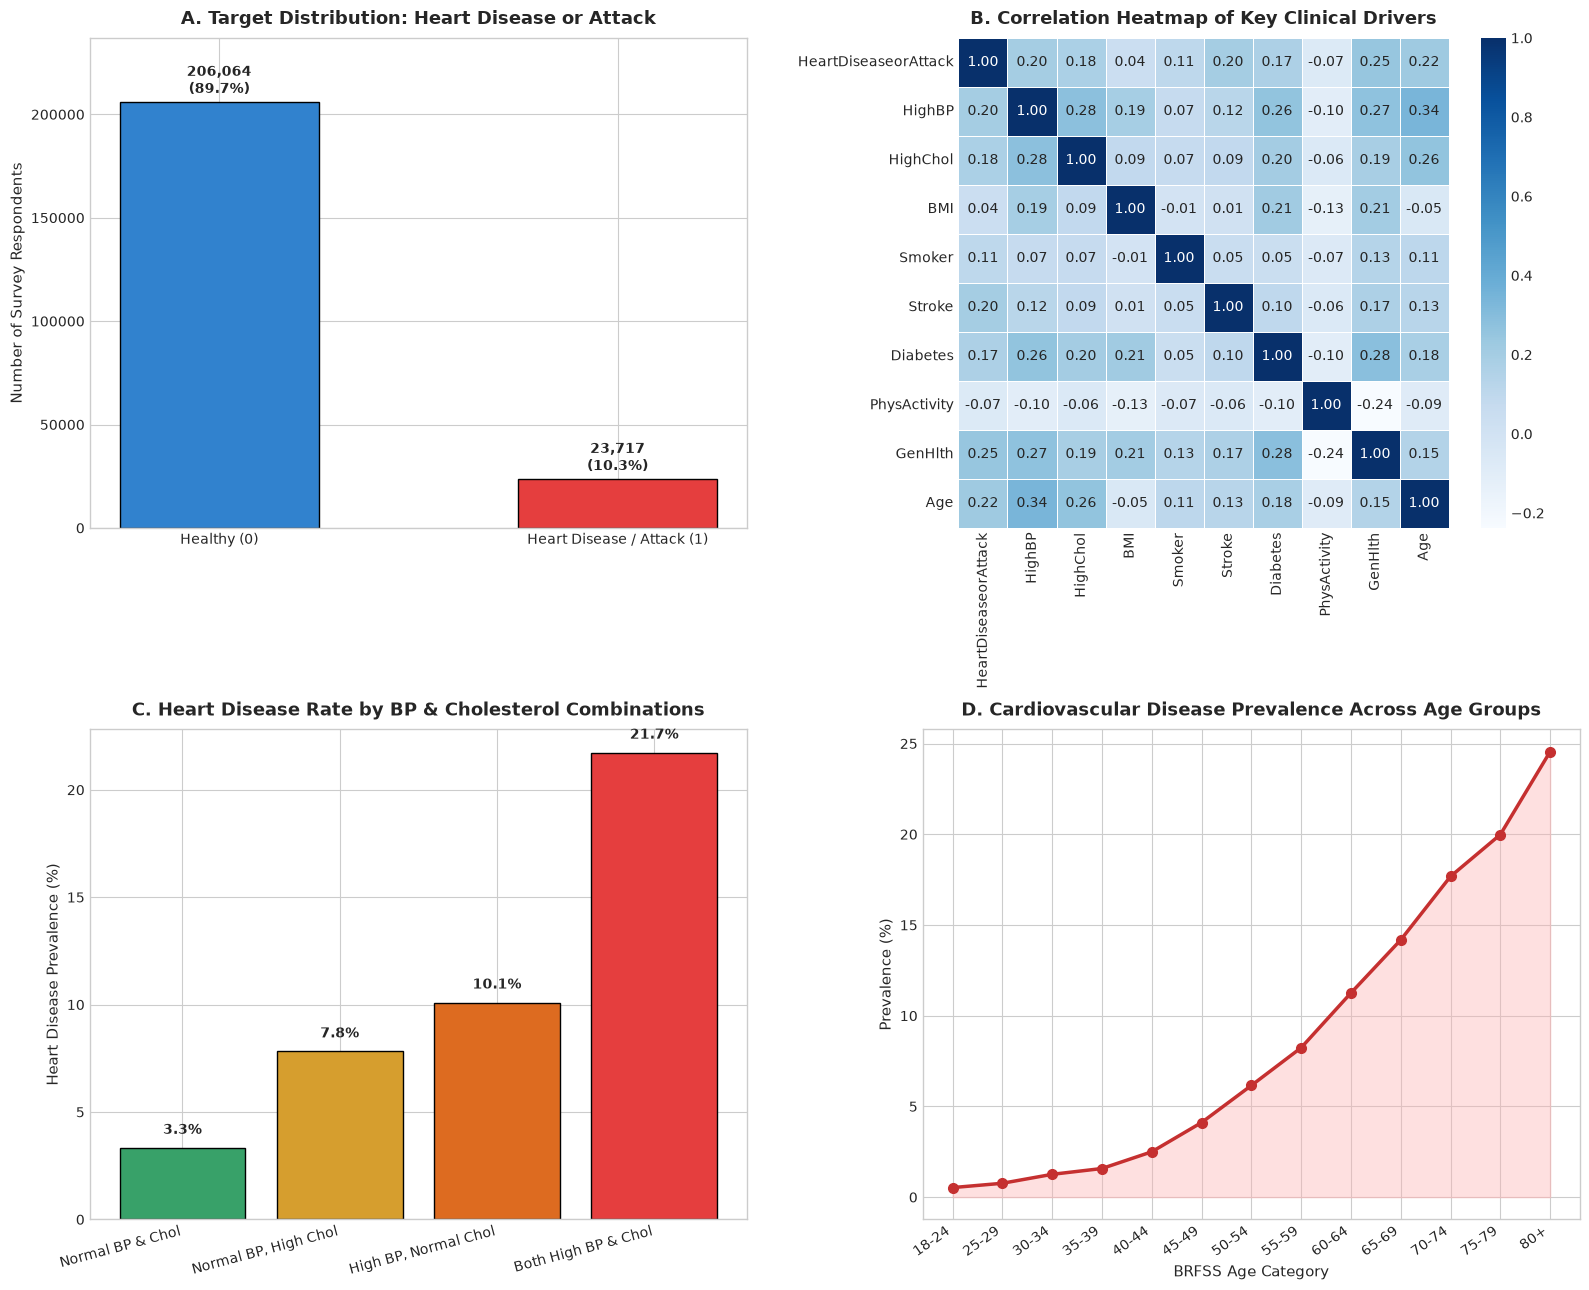

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# Plot 1: Target Variable Distribution
target_counts = df['HeartDiseaseorAttack'].value_counts()
colors = ['#3182ce', '#e53e3e']
bars = axes[0, 0].bar(['Healthy (0)', 'Heart Disease / Attack (1)'], target_counts.values, color=colors, width=0.5, edgecolor='black')
axes[0, 0].set_title('A. Target Distribution: Heart Disease or Attack', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].set_ylabel('Number of Survey Respondents', fontsize=11)
for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df)) * 100
    axes[0, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 2000, f"{yval:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0, 0].set_ylim(0, max(target_counts.values) * 1.15)

# Plot 2: Correlation Heatmap Matrix
key_features = ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'GenHlth', 'Age']
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 1], cbar=True, square=True, linewidths=0.5)
axes[0, 1].set_title('B. Correlation Heatmap of Key Clinical Drivers', fontsize=13, fontweight='bold', pad=10)

# Plot 3: Grouped Analysis - HighBP & HighChol vs Heart Disease
combo = df.groupby(['HighBP', 'HighChol'])['HeartDiseaseorAttack'].mean() * 100
combo_df = combo.reset_index()
labels = [
    'Normal BP & Chol',
    'Normal BP, High Chol',
    'High BP, Normal Chol',
    'Both High BP & Chol'
]
combo_bars = axes[1, 0].bar(labels, combo_df['HeartDiseaseorAttack'], color=['#38a169', '#d69e2e', '#dd6b20', '#e53e3e'], edgecolor='black')
axes[1, 0].set_title('C. Heart Disease Rate by BP & Cholesterol Combinations', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].set_ylabel('Heart Disease Prevalence (%)', fontsize=11)
axes[1, 0].set_xticklabels(labels, rotation=15, ha='right')
for bar in combo_bars:
    yval = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Age Gradient Analysis
age_labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
age_prev = (df.groupby('Age')['HeartDiseaseorAttack'].mean() * 100).values
axes[1, 1].plot(age_labels, age_prev, marker='o', color='#c53030', linewidth=2.5, markersize=7)
axes[1, 1].fill_between(age_labels, age_prev, color='#feb2b2', alpha=0.4)
axes[1, 1].set_title('D. Cardiovascular Disease Prevalence Across Age Groups', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].set_ylabel('Prevalence (%)', fontsize=11)
axes[1, 1].set_xlabel('BRFSS Age Category', fontsize=11)
axes[1, 1].set_xticklabels(age_labels, rotation=35, ha='right')

plt.tight_layout()
plt.show()

## Step 5: Machine Learning Modeling Pipeline
### Methodology:
1. **Feature-Target Separation:** Isolate target `HeartDiseaseorAttack` ($y$) and predictor matrix ($X$, 21 features).
2. **Stratified Splitting:** 80% training set and 20% validation split preserving the 10.3% positive class distribution.
3. **Feature Normalization:** Standardize features with `StandardScaler` ($\mu=0, \sigma=1$) to equalize scales for gradient and distance computations.
4. **Model Training:**
   - **Candidate 1: Logistic Regression** (Linear baseline with class-weight compensation).
   - **Candidate 2: Random Forest Classifier** (Non-linear ensemble with balanced subsampling).

In [5]:
target_col = 'HeartDiseaseorAttack'
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = list(X.columns)

# Stratified 80/20 train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples:   {X_train.shape[0]:,} ({y_train.mean()*100:.2f}% positive)")
print(f"Validation samples: {X_val.shape[0]:,} ({y_val.mean()*100:.2f}% positive)")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 1. Logistic Regression Model
print("\nTraining Logistic Regression (class_weight='balanced')...")
lr_model = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. Random Forest Classifier Model
print("Training Random Forest Classifier (class_weight='balanced')...")
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    max_samples=0.6,
    class_weight='balanced',
    random_state=42,
    n_jobs=2
)
rf_model.fit(X_train_scaled, y_train)

print("Both models successfully trained!")

Training samples:   183,824 (10.32% positive)
Validation samples: 45,957 (10.32% positive)

Training Logistic Regression (class_weight='balanced')...


Training Random Forest Classifier (class_weight='balanced')...


Both models successfully trained!


## Step 6: Model Evaluation & Performance Benchmarking
In clinical screening systems, sensitivity (Recall) is paramount to avoid missing vulnerable individuals. We compute:
- **Overall Accuracy**
- **Precision, Recall, and F1-Score**
- **ROC-AUC Score**
- **Confusion Matrix Analysis**
- **ROC Curve Comparison**

In [6]:
# Generate predictions & probabilities
y_pred_lr = lr_model.predict(X_val_scaled)
y_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

y_pred_rf = rf_model.predict(X_val_scaled)
y_prob_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

# Metric compilation
benchmark_results = [
    {
        'Model': 'Logistic Regression (Class-Weighted)',
        'Accuracy (%)': round(accuracy_score(y_val, y_pred_lr) * 100, 2),
        'Precision (%)': round(precision_score(y_val, y_pred_lr) * 100, 2),
        'Recall (%)': round(recall_score(y_val, y_pred_lr) * 100, 2),
        'F1-Score (%)': round(f1_score(y_val, y_pred_lr) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_val, y_prob_lr), 4)
    },
    {
        'Model': 'Random Forest Classifier (Balanced)',
        'Accuracy (%)': round(accuracy_score(y_val, y_pred_rf) * 100, 2),
        'Precision (%)': round(precision_score(y_val, y_pred_rf) * 100, 2),
        'Recall (%)': round(recall_score(y_val, y_pred_rf) * 100, 2),
        'F1-Score (%)': round(f1_score(y_val, y_pred_rf) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_val, y_prob_rf), 4)
    }
]

df_benchmark = pd.DataFrame(benchmark_results)
print("=== CLASSIFICATION BENCHMARK SUMMARY ===")
print(df_benchmark.to_string(index=False))

print("\n=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred_lr, target_names=['Healthy (0)', 'Heart Risk (1)']))

print("=== RANDOM FOREST CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred_rf, target_names=['Healthy (0)', 'Heart Risk (1)']))

=== CLASSIFICATION BENCHMARK SUMMARY ===
                               Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC
Logistic Regression (Class-Weighted)         73.92          25.24       77.82         38.11   0.8355
 Random Forest Classifier (Balanced)         74.02          25.34       77.97         38.25   0.8341

=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

   Healthy (0)       0.97      0.73      0.83     41214
Heart Risk (1)       0.25      0.78      0.38      4743

      accuracy                           0.74     45957
     macro avg       0.61      0.76      0.61     45957
  weighted avg       0.89      0.74      0.79     45957

=== RANDOM FOREST CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

   Healthy (0)       0.97      0.74      0.84     41214
Heart Risk (1)       0.25      0.78      0.38      4743

      accuracy                           0.74     45

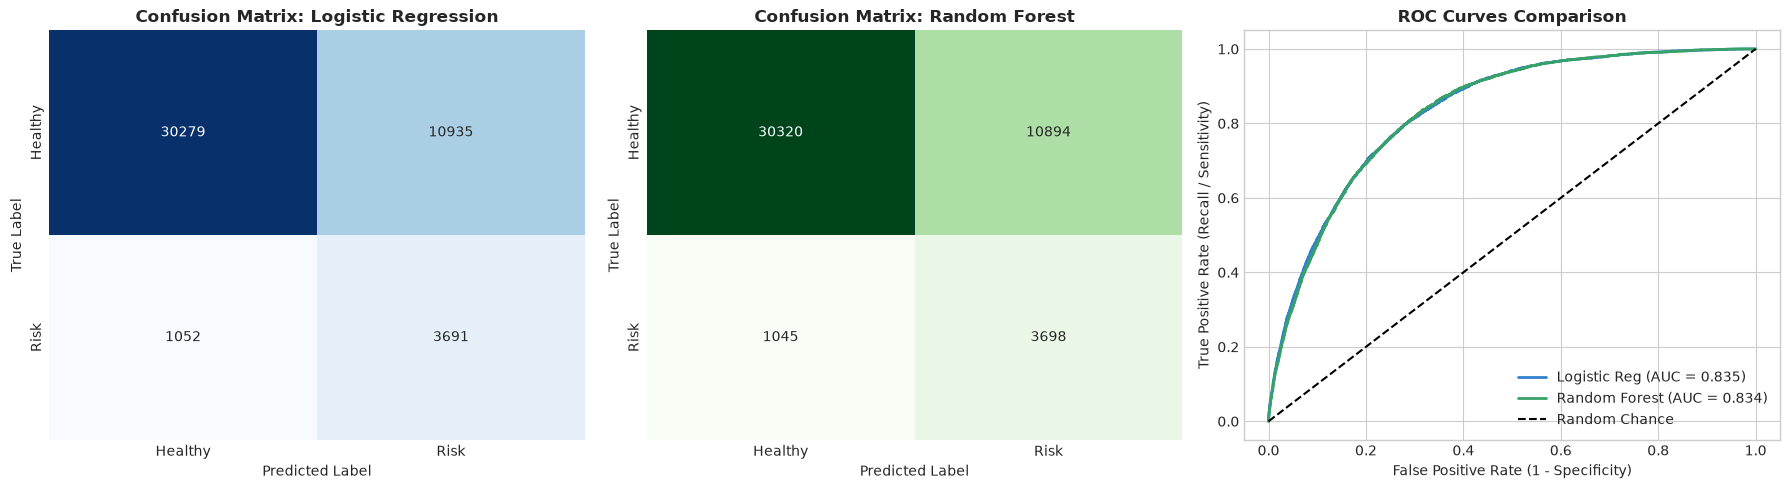

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix 1: Logistic Regression
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix: Logistic Regression', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Healthy', 'Risk'])
axes[0].set_yticklabels(['Healthy', 'Risk'])

# Confusion Matrix 2: Random Forest
cm_rf = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix: Random Forest', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['Healthy', 'Risk'])
axes[1].set_yticklabels(['Healthy', 'Risk'])

# ROC Curves Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf)

axes[2].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC = {roc_auc_score(y_val, y_prob_lr):.3f})", color='#3182ce', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_val, y_prob_rf):.3f})", color='#38a169', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[2].set_title('ROC Curves Comparison', fontweight='bold')
axes[2].set_xlabel('False Positive Rate (1 - Specificity)')
axes[2].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Step 7: Feature Importance & Clinical Risk Drivers
We analyze the Gini importance values from the Random Forest model and standardized coefficients from Logistic Regression to identify which traits drive risk predictions most significantly.

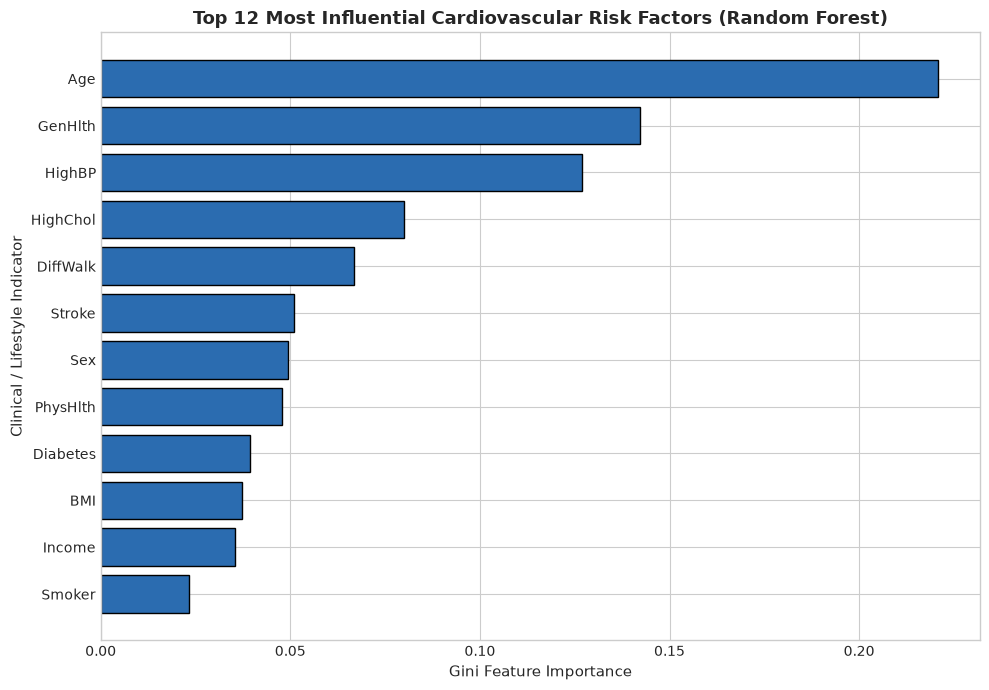

Top 5 Predictive Indicators:
  - Age: 0.2208
  - GenHlth: 0.1423
  - HighBP: 0.1270
  - HighChol: 0.0800
  - DiffWalk: 0.0668


In [8]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp['Feature'].tail(12), feat_imp['Importance'].tail(12), color='#2b6cb0', edgecolor='black')
plt.title('Top 12 Most Influential Cardiovascular Risk Factors (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Gini Feature Importance', fontsize=11)
plt.ylabel('Clinical / Lifestyle Indicator', fontsize=11)
plt.tight_layout()
plt.show()

print("Top 5 Predictive Indicators:")
for idx, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f"  - {row['Feature']}: {row['Importance']:.4f}")

## Step 8: Model Serialization & Production Export
We serialize the trained artifacts into `models/` directory for zero-latency inference inside the Streamlit frontend (`app.py`).

In [9]:
os.makedirs('models', exist_ok=True)

joblib.dump(scaler, os.path.join('models', 'scaler.joblib'))
joblib.dump(rf_model, os.path.join('models', 'heart_risk_model.joblib'))
joblib.dump(lr_model, os.path.join('models', 'logistic_regression_model.joblib'))

metadata = {
    "project_name": "Healthcare Risk Predictor",
    "student_name": "Roshani Jadhav",
    "internship": "AICTE | IBM SkillsBuild Data Analytics with AI",
    "partner": "BharatCares",
    "feature_names": feature_names,
    "metrics_rf": benchmark_results[1],
    "metrics_lr": benchmark_results[0]
}

with open(os.path.join('models', 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print("Exported artifacts:")
print("  - models/scaler.joblib")
print("  - models/heart_risk_model.joblib")
print("  - models/logistic_regression_model.joblib")
print("  - models/model_metadata.json")

Exported artifacts:
  - models/scaler.joblib
  - models/heart_risk_model.joblib
  - models/logistic_regression_model.joblib
  - models/model_metadata.json


## Step 9: Sample Patient Risk Inference Simulation
Demonstrating real-time scoring on a sample prospective patient presenting with Hypertension, High Cholesterol, and elevated BMI.

In [10]:
# Sample patient clinical record
sample_patient = {
    'HighBP': 1,
    'HighChol': 1,
    'CholCheck': 1,
    'BMI': 31.5,
    'Smoker': 1,
    'Stroke': 0,
    'Diabetes': 1,
    'PhysActivity': 0,
    'Fruits': 1,
    'Veggies': 1,
    'HvyAlcoholConsump': 0,
    'AnyHealthcare': 1,
    'NoDocbcCost': 0,
    'GenHlth': 4,
    'MentHlth': 5,
    'PhysHlth': 10,
    'DiffWalk': 1,
    'Sex': 1,
    'Age': 10,  # 65-69 years
    'Education': 4,
    'Income': 5
}

df_patient = pd.DataFrame([sample_patient])[feature_names]
scaled_patient = scaler.transform(df_patient)
patient_prob = rf_model.predict_proba(scaled_patient)[0, 1]
risk_classification = "High Risk Profile" if patient_prob >= 0.50 else "Low Risk Profile"

print("=" * 55)
print("PATIENT RISK PROFILE EVALUATION")
print("=" * 55)
print(f"Calculated Cardiac Risk Probability: {patient_prob*100:.2f}%")
print(f"Stratified Classification:          {risk_classification}")
print("=" * 55)

PATIENT RISK PROFILE EVALUATION
Calculated Cardiac Risk Probability: 84.46%
Stratified Classification:          High Risk Profile
